In [19]:
import pandas as pd
import numpy as np
df = pd.read_csv("matches.csv")
df

,match_id,date,stage,group,team_1,team_2,score_1,score_2,winner,decided_by_penalties,notes
0,1,2026-06-11,Group Stage,A,Mexico,South Africa,2,0,Mexico,No,Tournament opening match at Estadio Azteca
1,2,2026-06-11,Group Stage,A,South Korea,Czechia,2,1,South Korea,No,NaN
2,3,2026-06-12,Group Stage,B,Canada,Bosnia and Herzegovina,1,1,Draw,No,NaN
3,4,2026-06-12,Group Stage,D,United States,Paraguay,4,1,United States,No,NaN
4,5,2026-06-13,Group Stage,B,Switzerland,Qatar,1,1,Draw,No,NaN
...,...,...,...,...,...,...,...,...,...,...,...
87,88,2026-07-03,Round of 32,NaN,Colombia,Ghana,1,0,Colombia,No,NaN
88,89,2026-07-04,Round of 16,NaN,Morocco,Canada,3,0,Morocco,No,Morocco eliminates co-host Canada
89,90,2026-07-04,Round of 16,NaN,France,Paraguay,1,0,France,No,NaN
90,91,2026-07-05,Round of 16,NaN,Norway,Brazil,2,1,Norway,No,NaN


In [20]:
df.shape

(92, 11)

In [21]:
df.isnull().sum()

match_id                 0
date                     0
stage                    0
group                   20
team_1                   0
team_2                   0
score_1                  0
score_2                  0
winner                   0
decided_by_penalties     0
notes                   86
dtype: int64

### Since there are large number of nulls , if i use the drop method then there would be no data left for analysis instead am using fill method for further analysis .

In [22]:
null_rows = df[df["group"].isnull() | df["notes"].isnull()]
print(null_rows.shape)

(90, 11)


In [23]:
df["group"].fillna("Knockout", inplace=True)

C:\Users\rahul\AppData\Local\Temp\ipykernel_10032\2900348836.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["group"].fillna("Knockout", inplace=True)


In [24]:
df["notes"].fillna("No Notes", inplace=True)

C:\Users\rahul\AppData\Local\Temp\ipykernel_10032\4237920929.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["notes"].fillna("No Notes", inplace=True)


In [25]:
df.isnull().sum()

match_id                0
date                    0
stage                   0
group                   0
team_1                  0
team_2                  0
score_1                 0
score_2                 0
winner                  0
decided_by_penalties    0
notes                   0
dtype: int64

In [26]:
df.shape

(92, 11)

In [27]:
df

,match_id,date,stage,group,team_1,team_2,score_1,score_2,winner,decided_by_penalties,notes
0,1,2026-06-11,Group Stage,A,Mexico,South Africa,2,0,Mexico,No,Tournament opening match at Estadio Azteca
1,2,2026-06-11,Group Stage,A,South Korea,Czechia,2,1,South Korea,No,No Notes
2,3,2026-06-12,Group Stage,B,Canada,Bosnia and Herzegovina,1,1,Draw,No,No Notes
3,4,2026-06-12,Group Stage,D,United States,Paraguay,4,1,United States,No,No Notes
4,5,2026-06-13,Group Stage,B,Switzerland,Qatar,1,1,Draw,No,No Notes
...,...,...,...,...,...,...,...,...,...,...,...
87,88,2026-07-03,Round of 32,Knockout,Colombia,Ghana,1,0,Colombia,No,No Notes
88,89,2026-07-04,Round of 16,Knockout,Morocco,Canada,3,0,Morocco,No,Morocco eliminates co-host Canada
89,90,2026-07-04,Round of 16,Knockout,France,Paraguay,1,0,France,No,No Notes
90,91,2026-07-05,Round of 16,Knockout,Norway,Brazil,2,1,Norway,No,No Notes


In [28]:
df.isnull().sum()

match_id                0
date                    0
stage                   0
group                   0
team_1                  0
team_2                  0
score_1                 0
score_2                 0
winner                  0
decided_by_penalties    0
notes                   0
dtype: int64

In [29]:
df.duplicated().sum()

np.int64(0)

## 1) Exploratory Data Analysis

In [30]:
# 1_ EDA
df.describe()
df.info()
df["winner"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   match_id              92 non-null     int64 
 1   date                  92 non-null     object
 2   stage                 92 non-null     object
 3   group                 92 non-null     object
 4   team_1                92 non-null     object
 5   team_2                92 non-null     object
 6   score_1               92 non-null     int64 
 7   score_2               92 non-null     int64 
 8   winner                92 non-null     object
 9   decided_by_penalties  92 non-null     object
 10  notes                 92 non-null     object
dtypes: int64(3), object(8)
memory usage: 8.0+ KB


winner
Draw                      20
France                     5
Mexico                     4
Morocco                    4
Norway                     4
England                    4
Argentina                  4
Spain                      3
Colombia                   3
United States              3
Switzerland                3
Brazil                     3
Belgium                    2
Germany                    2
Canada                     2
Paraguay                   2
Netherlands                2
Ivory Coast                2
Portugal                   2
Croatia                    2
Egypt                      2
South Korea                1
Ghana                      1
Scotland                   1
Austria                    1
Australia                  1
Sweden                     1
Algeria                    1
Japan                      1
Bosnia and Herzegovina     1
South Africa               1
Turkiye                    1
Ecuador                    1
Senegal                    1
DR Cong

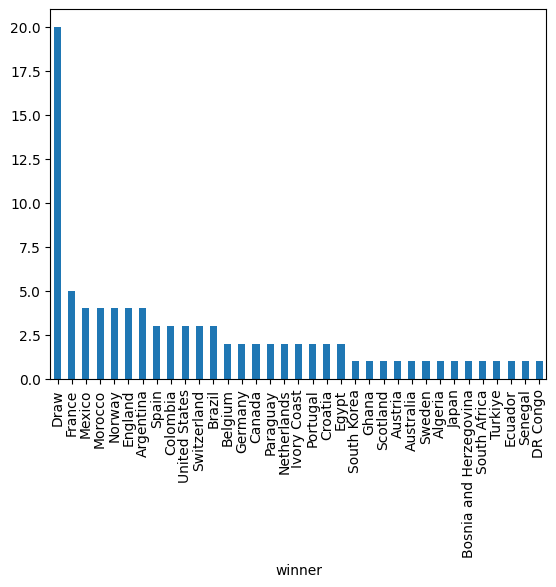

In [41]:
import matplotlib.pyplot as plt

df["winner"].value_counts().plot(kind="bar")
plt.show()

### x-axis represents the winners .
### y-axis represents the number of matches won by that team [ Ex : France won 5 matches]
### Draws were the most frequent outcome, followed by Mexico and several other teams. This analysis helps identify the most successful teams and the overall pattern of match results in the dataset.

## 2) Feature Engineering

In [108]:
# 2) Feature Engineering is the process of creating new, useful features (columns) from existing data to help a machine learning model learn patterns better
df["total_goals"] = df["score_1"] + df["score_2"]
df["goal_difference"] = abs(df["score_1"] - df["score_2"])

In [45]:
df

,match_id,date,stage,group,team_1,team_2,score_1,score_2,winner,decided_by_penalties,notes,total_goals,goal_difference,year
0,1,2026-06-11,Group Stage,A,Mexico,South Africa,2,0,Mexico,NaN,Tournament opening match at Estadio Azteca,2,2,2026
1,2,2026-06-11,Group Stage,A,South Korea,Czechia,2,1,South Korea,NaN,No Notes,3,1,2026
2,3,2026-06-12,Group Stage,B,Canada,Bosnia and Herzegovina,1,1,Draw,NaN,No Notes,2,0,2026
3,4,2026-06-12,Group Stage,D,United States,Paraguay,4,1,United States,NaN,No Notes,5,3,2026
4,5,2026-06-13,Group Stage,B,Switzerland,Qatar,1,1,Draw,NaN,No Notes,2,0,2026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,88,2026-07-03,Round of 32,Knockout,Colombia,Ghana,1,0,Colombia,NaN,No Notes,1,1,2026
88,89,2026-07-04,Round of 16,Knockout,Morocco,Canada,3,0,Morocco,NaN,Morocco eliminates co-host Canada,3,3,2026
89,90,2026-07-04,Round of 16,Knockout,France,Paraguay,1,0,France,NaN,No Notes,1,1,2026
90,91,2026-07-05,Round of 16,Knockout,Norway,Brazil,2,1,Norway,NaN,No Notes,3,1,2026


### Feature engineering is the process of creating new meaningful features from existing data. In this dataset, features such as total goals, goal difference, penalty indicator, and year were created from existing columns to improve analysis and machine learning model performance

## 3) Encoding

In [50]:
# 3) Encode Categorical Values
# Machine Learning models cannot understand text (string) data directly. They only work with numbers.
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["winner"] = le.fit_transform(df["winner"])

In [51]:
print(dict(zip(le.classes_, le.transform(le.classes_))))

{np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(3), np.int64(4): np.int64(4), np.int64(5): np.int64(5), np.int64(6): np.int64(6), np.int64(7): np.int64(7), np.int64(8): np.int64(8), np.int64(9): np.int64(9), np.int64(10): np.int64(10), np.int64(11): np.int64(11), np.int64(12): np.int64(12), np.int64(13): np.int64(13), np.int64(14): np.int64(14), np.int64(15): np.int64(15), np.int64(16): np.int64(16), np.int64(17): np.int64(17), np.int64(18): np.int64(18), np.int64(19): np.int64(19), np.int64(20): np.int64(20), np.int64(21): np.int64(21), np.int64(22): np.int64(22), np.int64(23): np.int64(23), np.int64(24): np.int64(24), np.int64(25): np.int64(25), np.int64(26): np.int64(26), np.int64(27): np.int64(27), np.int64(28): np.int64(28), np.int64(29): np.int64(29), np.int64(30): np.int64(30), np.int64(31): np.int64(31), np.int64(32): np.int64(32), np.int64(33): np.int64(33), np.int64(34): np.int64(34)}


In [52]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in ["stage","group","team_1","team_2","winner","decided_by_penalties"]:
    df[col] = le.fit_transform(df[col])

In [53]:
df

,match_id,date,stage,group,team_1,team_2,score_1,score_2,winner,decided_by_penalties,notes,total_goals,goal_difference,year
0,1,2026-06-11,0,0,22,33,2,0,20,0,Tournament opening match at Estadio Azteca,2,2,2026
1,2,2026-06-11,0,0,32,9,2,1,29,0,No Notes,3,1,2026
2,3,2026-06-12,0,1,7,3,1,1,11,0,No Notes,2,0,2026
3,4,2026-06-12,0,3,37,27,4,1,34,0,No Notes,5,3,2026
4,5,2026-06-13,0,1,35,29,1,1,11,0,No Notes,2,0,2026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,88,2026-07-03,2,11,9,14,1,0,8,0,No Notes,1,1,2026
88,89,2026-07-04,1,11,23,5,3,0,21,0,Morocco eliminates co-host Canada,3,3,2026
89,90,2026-07-04,1,11,16,27,1,0,15,0,No Notes,1,1,2026
90,91,2026-07-05,1,11,25,4,2,1,23,0,No Notes,3,1,2026


### Encoding is the process of converting categorical or text data into numerical values because machine learning algorithms can only process numbers. In this project, columns such as team names, match stage, group, winner, and penalty status were encoded using Label Encoding before model training.

## 4)Feature Selection

In [55]:
# 4) Feature Selection : Feature Selection is the process of choosing the most important columns (features) that will be used to train a machine learning model
X = df[["team_1", "team_2", "score_1", "score_2"]]
y = df["winner"]

# Feature Selection is the process of selecting relevant features from a dataset for model training. It helps remove unnecessary data, reduces 
# complexity, and improves the efficiency and performance of machine learning models. In this project, relevant match-related columns were selected as
# input features, while the winner column was chosen as the target variable.

## 5) Train Test Split

In [130]:
# 5) Train Test Split 
# Train-Test Split is the process of dividing the dataset into two parts:

# Training Data – Used to train the machine learning model.
# Testing Data – Used to evaluate how well the model performs on unseen data.
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)
print("Training Set :",len(X_train))
print("Testing Set :",len(X_test))

# Train-Test Split is the process of dividing a dataset into training and testing sets. The training set is used to train the machine learning model,
# while the testing set is used to evaluate its performance on unseen data. It is necessary to prevent overfitting and to ensure that the model can
# generalize well to new data. Typically, 80% of the data is used for training and 20% for testing.

Training Set : 73
Testing Set : 19


## 6)Model Building

In [131]:
# 6) Model Building : Model Building is the process of training a machine learning algorithm using the training data so that it can learn patterns and make predictions on new, unseen data
# Train a Machine learning model
# not really necessary 
#from sklearn.linear_model import LinearRegression
#model = LinearRegression()
#model.fit(X_train,y_train)

### This output means your Linear Regression model has been successfully created and trained

In [132]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### This output means your Random Forest Classifier has been successfully created and trained on the training data.

In [133]:
# 7) Prediction 
predictions = model.predict(X_test)
predictions[:5]
# Prediction is the process of using a trained machine learning model to generate outputs for unseen data. After training, the model uses the testing 
# dataset to predict the target variable. In this project, the trained model predicts the match winner based on the selected input features.

array([15, 14, 11, 11, 20])

In [135]:
# 8) Model Evaluation:Model Evaluation is the process of measuring how well the machine learning model performs on unseen data.
# For Regression
#from sklearn.metrics import r2_score

#print(r2_score(y_test, predictions))

In [136]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, predictions))

0.47368421052631576


In [137]:
df

,match_id,date,stage,group,team_1,team_2,score_1,score_2,winner,decided_by_penalties,notes,total_goals,goal_difference,year
0,1,2026-06-11,0,0,22,33,2,0,20,0,Tournament opening match at Estadio Azteca,2,2,2026
1,2,2026-06-11,0,0,32,9,2,1,29,0,No Notes,3,1,2026
2,3,2026-06-12,0,1,7,3,1,1,11,0,No Notes,2,0,2026
3,4,2026-06-12,0,3,37,27,4,1,34,0,No Notes,5,3,2026
4,5,2026-06-13,0,1,35,29,1,1,11,0,No Notes,2,0,2026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,88,2026-07-03,2,11,9,14,1,0,8,0,No Notes,1,1,2026
88,89,2026-07-04,1,11,23,5,3,0,21,0,Morocco eliminates co-host Canada,3,3,2026
89,90,2026-07-04,1,11,16,27,1,0,15,0,No Notes,1,1,2026
90,91,2026-07-05,1,11,25,4,2,1,23,0,No Notes,3,1,2026


## Checking that the Data is Ready

In [138]:
df.shape

(92, 14)

In [139]:
df.isnull().sum()

match_id                0
date                    0
stage                   0
group                   0
team_1                  0
team_2                  0
score_1                 0
score_2                 0
winner                  0
decided_by_penalties    0
notes                   0
total_goals             0
goal_difference         0
year                    0
dtype: int64

In [140]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   match_id              92 non-null     int64         
 1   date                  92 non-null     datetime64[ns]
 2   stage                 92 non-null     int64         
 3   group                 92 non-null     int64         
 4   team_1                92 non-null     int64         
 5   team_2                92 non-null     int64         
 6   score_1               92 non-null     int64         
 7   score_2               92 non-null     int64         
 8   winner                92 non-null     int64         
 9   decided_by_penalties  92 non-null     int64         
 10  notes                 92 non-null     object        
 11  total_goals           92 non-null     int64         
 12  goal_difference       92 non-null     int64         
 13  year                  

In [141]:
df.duplicated().sum()

np.int64(0)

In [142]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(73, 4)
(19, 4)
(73,)
(19,)


In [143]:
print(predictions[:10])
#Make sure predictions are being generated without errors

[15 14 11 11 20 32 34  3 21 27]


In [144]:
comparison = pd.DataFrame({'Actual': y_test,'Predicted': predictions})

print(comparison.head(20))

    Actual  Predicted
40      15         15
22      14         14
55      11         11
72       7         11
0       20         20
26      32         32
39      11         34
67       1          3
10      11         21
44      25         27
83      25         23
35      19         15
89      15         17
62      11         11
12      11         11
4       11         11
18       1          1
28      21         20
49      28         20


In [145]:
print(len(y_test))
print((y_test == predictions).sum())

19
9


### Total Test Matches = 19  & Correctly Predicted = 9 , Therefore 8/19*100 = 42%

In [146]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.47368421052631576


In [147]:
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 1.0
Test Accuracy: 0.47368421052631576


### The training accuracy of 100% indicates that the Random Forest model correctly classified all training samples. However, the testing accuracy of 52.63% shows that the model's performance decreased on unseen data. The large difference between training and testing accuracy suggests overfitting, meaning the model learned the training data very well but did not generalize equally well to new data. 